In [32]:
from MASSIVE.analytes import Oligo
import matplotlib.pyplot as plt

In [33]:
# some pretty colours to distinguish the 4 base oligos
blue = '#0072B2'
pink = '#CC6677'
green = '#44AA99'
gold = '#E69F00'

colours = [
    blue,
    pink,
    green,
    gold
]

In [34]:
#
base_oligos = [
    Oligo(name='base_3C', seq='GAAGACCACAACC'),  # blue
    Oligo(name='base_3T', seq='GAAGACCACAACT'),  # pink
    Oligo(name='base_3A', seq='GAAGACCACAACA'),  # green
    Oligo(name='base_3G', seq='GAAGACCACAACG'),  # gold
]

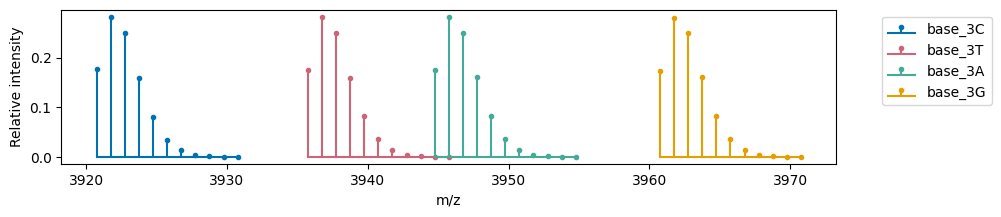

In [35]:
fig, ax = plt.subplots(figsize=(10,2))

for i, o in enumerate(base_oligos):
    o.plot(ax=ax, label=o.name, colour=colours[i], mass_labels=False)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlabel('m/z')
ax.set_ylabel('Relative intensity')

fig.savefig(fname='../images/base_oligos.svg', bbox_inches='tight', format='svg', transparent=False)

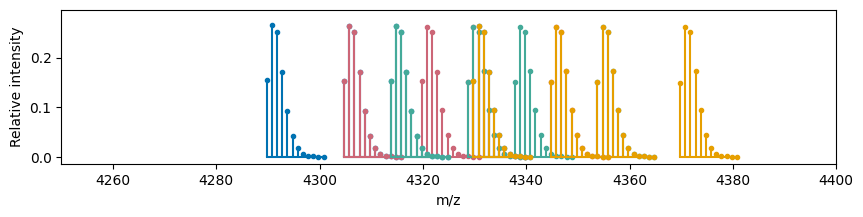

In [36]:
fig, ax = plt.subplots(figsize=(10,2))

polymerization_options = ['G', 'T', 'C', 'A']

for i, o in enumerate(base_oligos):

    o.plot(ax=ax, label=o.name, colour=colours[i], mass_labels=False)

    for N in polymerization_options:
        o_pol = Oligo(seq=o.seq + N, name=f"{o.name}{N}", mods=[o.mods, '3P'])
        o_pol.plot(ax=ax, label=o_pol.name, colour=colours[i], mass_labels=False)

ax.legend(bbox_to_anchor=(1.05, 1), loc='center left')
ax.set_xlabel('m/z')
ax.set_ylabel('Relative intensity')

fig.savefig(fname='../images/polymerized_base_oligos.svg', bbox_inches='tight', format='svg', transparent=False)

ax.set_xlim((4250,4400))
plt.gca().legend_.remove()

fig.savefig(fname='../images/polymerized_base_oligos_zoom.svg', bbox_inches='tight', format='svg', transparent=False)

In [37]:
base_oligos = [
    Oligo(name='base_3C', seq='TGAAGACCACAACC', mods=None),  # blue
    Oligo(name='base_3T', seq= 'GAAGACCACAACT', mods='PS'),  # pink
    Oligo(name='base_3A', seq= 'GAAGACCACAACA', mods='5P'),  # green
    Oligo(name='base_3G', seq='GGAAGACCACAACG', mods=None),  # gold
]

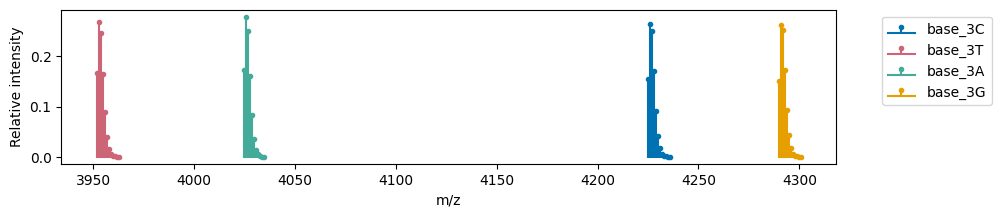

In [38]:
fig, ax = plt.subplots(figsize=(10,2))

for i, o in enumerate(base_oligos):
    o.plot(ax=ax, label=o.name, colour=colours[i], mass_labels=False)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlabel('m/z')
ax.set_ylabel('Relative intensity')
fig.savefig(fname='../images/base_oligos_redesigned.svg', bbox_inches='tight', format='svg', transparent=False)

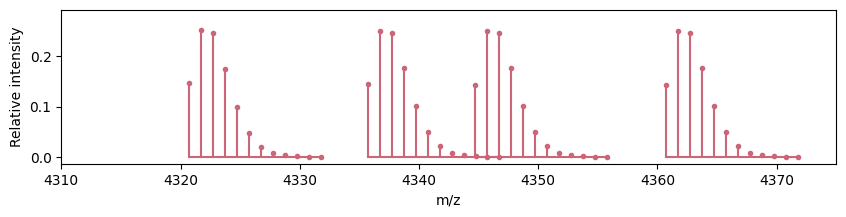

In [39]:
fig, ax = plt.subplots(figsize=(10,2))

for i, o in enumerate(base_oligos):

    o.plot(ax=ax, label=o.name, colour=colours[i], mass_labels=False)

    for N in polymerization_options:
        o_pol = Oligo(seq=o.seq + N, name=f"{o.name}{N}", mods=[o.mods, '3P'])
        o_pol.plot(ax=ax, label=o_pol.name, colour=colours[i], mass_labels=False)

ax.legend(bbox_to_anchor=(1.05, 1), loc='center left')
ax.set_xlabel('m/z')
ax.set_ylabel('Relative intensity')
fig.savefig(fname='../images/base_oligos_redesigned_polymerized.svg', bbox_inches='tight', format='svg', transparent=False)

ax.set_xlim((4310,4720))
plt.gca().legend_.remove()

fig.savefig(fname='../images/base_oligos_redesigned_polymerized_zoom.svg', bbox_inches='tight', format='svg', transparent=False)

ax.set_xlim((4310,4375))

fig.savefig(fname='../images/base_oligos_redesigned_polymerized_zoom2.svg', bbox_inches='tight', format='svg', transparent=False)

In [49]:
from itertools import combinations

all_analytes = base_oligos.copy()
for o in base_oligos:
    for N in polymerization_options:
        o_pol = Oligo(seq=o.seq + N, name=f"{o.name}{N}", mods=[o.mods, '3P'])
        all_analytes.append(o_pol)

def overlap(oligo1, oligo2):
    "returns true if oligos overlap in mass range"
    start1, end1 = oligo1.calc_iso_dist_range(cumulative_threshold=0.999, left_pad=0, right_pad=0)
    start2, end2 = oligo2.calc_iso_dist_range(cumulative_threshold=0.999, left_pad=0, right_pad=0)
    if start1 <= end2 and start2 <= end1:
        return True
    else:
        return False

num_overlaps = 0
non_overlapping = 0
for oligo1, oligo2 in combinations(all_analytes, 2):
    if overlap(oligo1, oligo2):
        num_overlaps += 1
    else:
        non_overlapping += 1

print(f"Number of overlapping oligo pairs: {num_overlaps}")
print(f"Number of non-overlapping oligo pairs: {non_overlapping}")

Number of overlapping oligo pairs: 0
Number of non-overlapping oligo pairs: 190
